In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


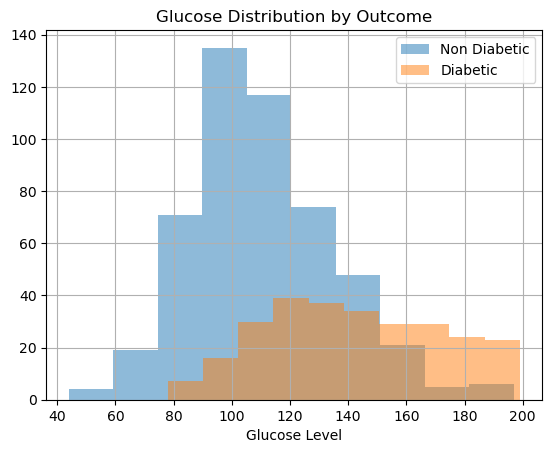

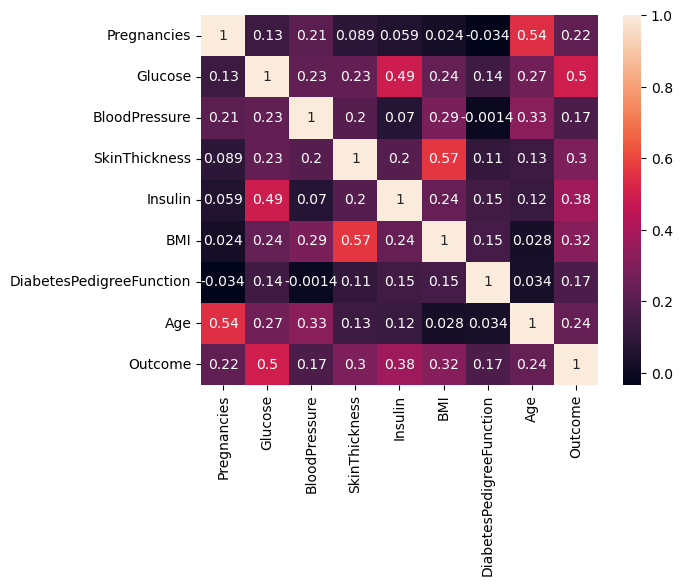

In [29]:
df[df['Outcome']==0]['Glucose'].hist(alpha=0.5, label='Non Diabetic')
df[df['Outcome']==1]['Glucose'].hist(alpha=0.5, label='Diabetic')
plt.legend()
plt.xlabel('Glucose Level')
plt.title('Glucose Distribution by Outcome')
plt.show()

sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
X = df.drop('Outcome', axis=1)  # all 8 columns
Y = df['Outcome']   
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
            

In [35]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [33]:
from sklearn.metrics import classification_report

y_pred_lr = (lr_model.predict_proba(X_test_scaled)[:,1] >= 0.4).astype(int)
y_pred_rf = (rf_model.predict_proba(X_test_scaled)[:,1] >= 0.4).astype(int)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.63      0.73      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154

Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        99
           1       0.73      0.89      0.80        55

    accuracy                           0.84       154
   macro avg       0.83      0.85      0.84       154
weighted avg       0.86      0.84      0.85       154

